In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [25]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
    --------------------------------------- 1.3/100.2 MB 9.6 MB/s eta 0:00:11
   - -------------------------------------- 2.6/100.2 MB 6.3 MB/s eta 0:00:16
   - -------------------------------------- 3.7/100.2 MB 5.9 MB/s eta 0:00:17
   - -------------------------------------- 4.7/100.2 MB 5.7 MB/s eta 0:00:17
   -- ------------------------------------- 5.8/100.2 MB 5.5 MB/s eta 0:00:18
   -- ------------------------------------- 6.8/100.2 MB 5.4 MB/s eta 0:00:18
   --- ------------------------------------ 8.1/100.2 MB 5.4 MB/s eta 0:00:18
   --- ------------------------------------ 9.2/100.2 MB 5.4 MB/s eta 0:00:17
   ---- ----------------------------------- 10.2/100.2 MB 5.4 MB/s eta 0:00:17
   ---- ----------------------------------- 11.5/100.2 MB 5.3 MB/s eta 0:00:17
   ----- ---------------------------------- 12.6/100.2 MB 5.3 MB/s et

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.3 MB 7.4 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.3 MB 6.0 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/11.3 MB 5.7 MB/s eta 0:00:02
   ---------------- ----------------------- 4.7/11.3 MB 5.6 MB/s eta 0:00:02
   -------------------- ------------------- 5.8/11.3 MB 5.4 MB/s eta 0:00:02
   ------------------------ --------------- 6.8/11.3 MB 5.4 MB/s eta 0:00:01
   --------------------------- ------------ 7.9/11.3 MB 5.2 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.3 MB 5.3 MB/s eta 0:00:01
   ------------------------------------ --- 10.2/11.3 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.3 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 5.1 MB/s  0:00:02

   -

In [4]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [7]:
df = pd.read_csv("rainfall (2).csv")

In [8]:
df.columns = df.columns.str.strip().str.lower()

In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            366 non-null    int64  
 1   pressure       366 non-null    float64
 2   maxtemp        366 non-null    float64
 3   temparature    366 non-null    float64
 4   mintemp        366 non-null    float64
 5   dewpoint       366 non-null    float64
 6   humidity       366 non-null    int64  
 7   cloud          366 non-null    int64  
 8   rainfall       366 non-null    object 
 9   sunshine       366 non-null    float64
 10  winddirection  365 non-null    float64
 11  windspeed      365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [10]:
df['rainfall'] = df['rainfall'].map({'yes': 1, 'no': 0})

In [11]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


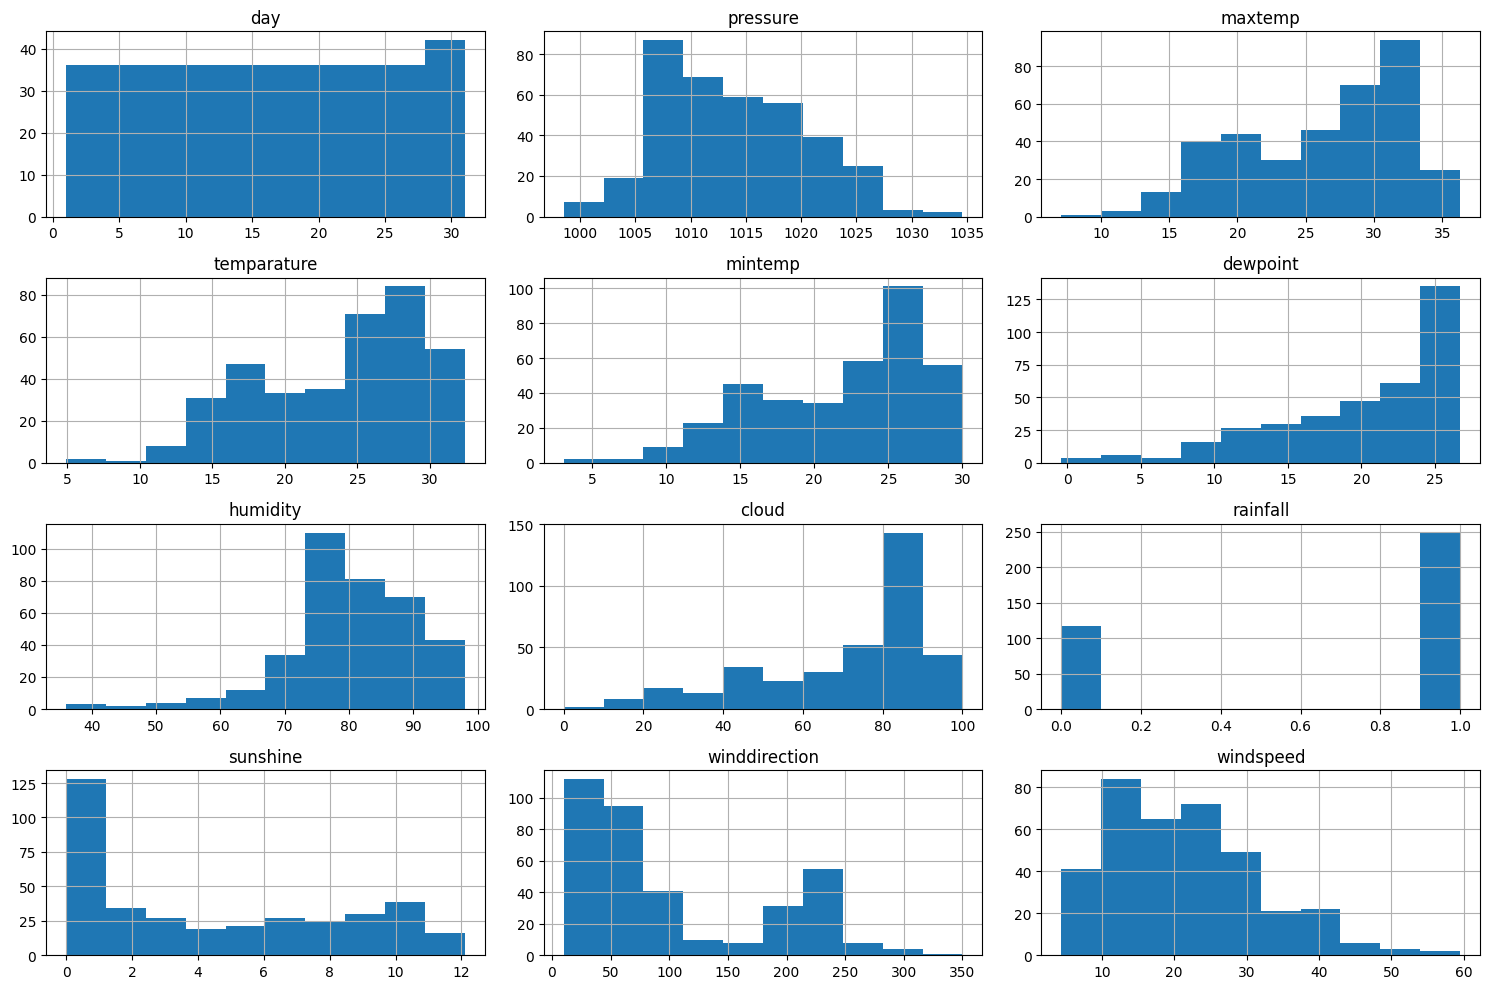

In [12]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

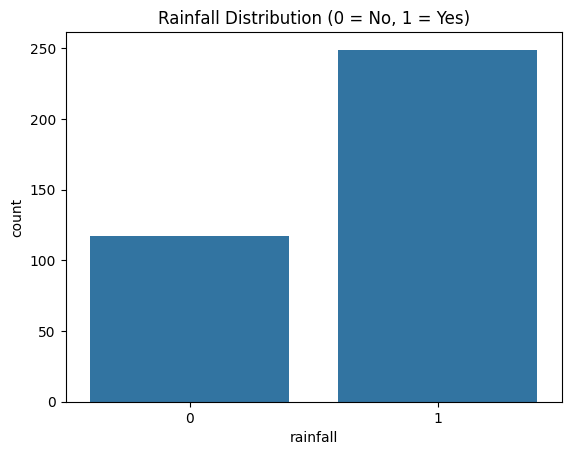

In [13]:
import seaborn as sns

sns.countplot(x='rainfall', data=df)
plt.title("Rainfall Distribution (0 = No, 1 = Yes)")
plt.show()

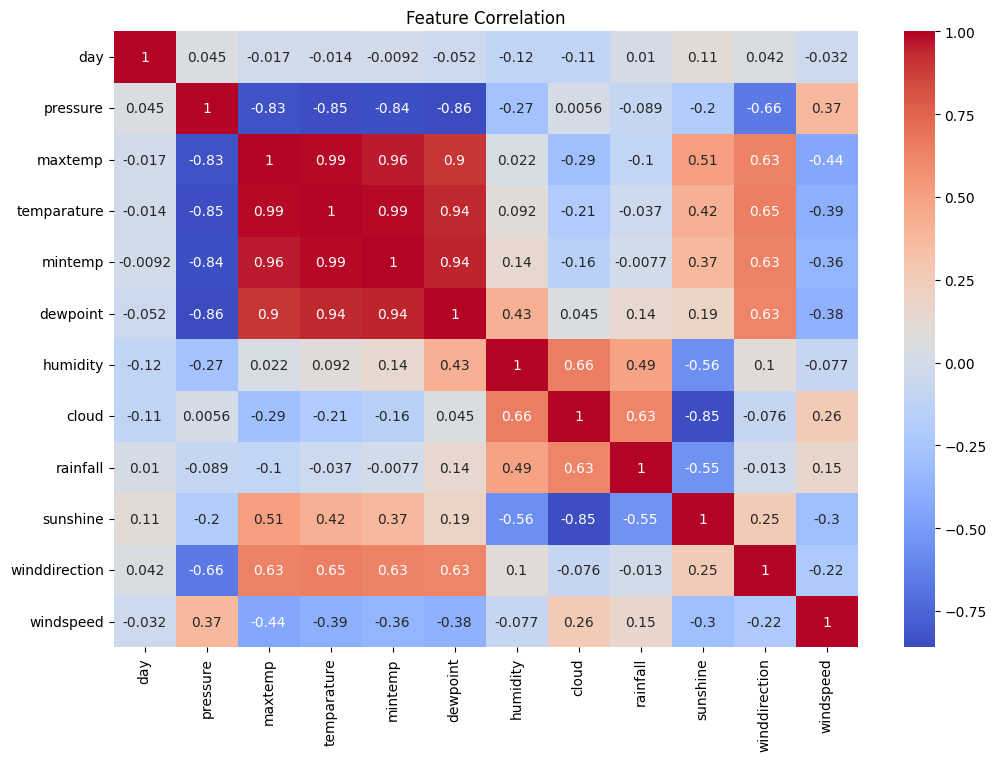

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


In [15]:
null_values = df.isnull().sum()
print(null_values)

day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    1
windspeed        1
dtype: int64


In [16]:
# Drop only rows where target is missing
df = df.dropna(subset=['rainfall'])

# Fill remaining numerical nulls
df.fillna(df.mean(numeric_only=True), inplace=True)

In [17]:
# Temperature
df['temp_range'] = df['maxtemp'] - df['mintemp']
df['temp_diff'] = df['temparature'] - df['mintemp']

# Moisture
df['dew_humidity_diff'] = df['humidity'] - df['dewpoint']
df['moisture_index'] = df['humidity'] * df['dewpoint']

# Cloud + Sunshine
df['cloud_sun_ratio'] = df['cloud'] / (df['sunshine'] + 1)
df['sunshine_inverse'] = 1 / (df['sunshine'] + 1)

# Wind
df['wind_effect'] = df['windspeed'] * df['cloud']
df['wind_dir_sin'] = np.sin(np.radians(df['winddirection']))
df['wind_dir_cos'] = np.cos(np.radians(df['winddirection']))

# Pressure
df['low_pressure_flag'] = (df['pressure'] < 1015).astype(int)
df['pressure_temp_ratio'] = df['pressure'] / (df['temparature'] + 1)

# Rain indicator
df['rain_indicator'] = df['humidity'] * df['cloud'] / (df['sunshine'] + 1)

# Cyclic feature
df['day_sin'] = np.sin(2 * np.pi * df['day'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 365)

In [18]:
df = df.dropna(subset=['rainfall'])
df.fillna(df.mean(numeric_only=True), inplace=True)

In [19]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [20]:
X = df.drop(columns=['rainfall', 'id'], errors='ignore')
y = df['rainfall']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
selector = SelectKBest(score_func=f_classif, k=15)

X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print("Selected Features:\n", selected_features)

X_train = pd.DataFrame(X_train, columns=selected_features)
X_test = pd.DataFrame(X_test, columns=selected_features)

Selected Features:
 Index(['maxtemp', 'temparature', 'humidity', 'cloud', 'sunshine', 'windspeed',
       'temp_range', 'temp_diff', 'dew_humidity_diff', 'moisture_index',
       'cloud_sun_ratio', 'sunshine_inverse', 'wind_effect', 'wind_dir_sin',
       'rain_indicator'],
      dtype='object')


In [23]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 9.6 MB/s eta 0:00:11
    --------------------------------------- 2.4/101.7 MB 6.7 MB/s eta 0:00:15
   - -------------------------------------- 3.4/101.7 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 4.5/101.7 MB 5.5 MB/s eta 0:00:18
   -- ------------------------------------- 5.8/101.7 MB 5.6 MB/s eta 0:00:18
   -- ------------------------------------- 6.8/101.7 MB 5.4 MB/s eta 0:00:18
   --- ------------------------------------ 7.9/101.7 MB 5.4 MB/s eta 0:00:18
   --- ------------------------------------ 8.9/101.7 MB 5.4 MB/s eta 0:00:18
   ---- ----------------------------------- 10.2/101.7 MB 5.4 MB/s eta 0:00:18
   ---- ----------------------------------- 11.3/101.7 MB 5.3 MB/s eta 0:00:17
   

In [27]:
models = {
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "CatBoost": CatBoostClassifier(verbose=0)
}


In [ ]:
print("\nCross Validation:")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: {scores.mean():.4f}")



Cross Validation:
SVM: 0.7576
Random Forest: 0.7975


C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [12:18:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [12:18:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [12:18:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:200: UserWarning: [12:18:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:7

XGBoost: 0.7756


In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
models["Tuned Random Forest"] = best_rf

print("\nBest RF Params:", grid.best_params_)

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    results[name] = {
        "accuracy": acc,
        "confusion_matrix": cm,
        "fpr": fpr,
        "tpr": tpr,
        "auc": roc_auc

    }

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("AUC:", roc_auc)

In [ ]:
for name in results:
    plt.figure(figsize=(5,4))
    sns.heatmap(results[name]["confusion_matrix"], annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
plt.figure(figsize=(8,6))

for name in results:
    plt.plot(results[name]["fpr"], results[name]["tpr"],
             label=f"{name} (AUC = {results[name]['auc']:.2f})")

plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
for name in results:
    print(f"{name}:")
    print("Accuracy:", results[name]["accuracy"])
    print("AUC:", results[name]["auc"])
    print("-"*30)

In [ ]:
best_model = max(results, key=lambda x: results[x]["accuracy"])
print("Best Model:", best_model)